## Linking Credit Cards to Cars

**0. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta
from collections import Counter

**1. Load and Prepare Data**

In [2]:
# Load GPS Tracking Data
gps_df = pd.read_csv('../cleaned_data/gps_data_cleaned.csv')

# Load Credit Card Transactions Data
cc_df = pd.read_csv('../cleaned_data/cc_data_cleaned.csv')

# Preview (optional)
print(gps_df.head())
print(cc_df.head())

# Make sure timestamps are parsed correctly
gps_df['timestamp'] = pd.to_datetime(gps_df['timestamp'])
cc_df['timestamp'] = pd.to_datetime(cc_df['timestamp'])

             timestamp  id        lat       long        date  hour  minute  \
0  2014-01-06 06:28:01  35  36.076225  24.874689  2014-01-06     6      28   
1  2014-01-06 06:28:01  35  36.076220  24.874596  2014-01-06     6      28   
2  2014-01-06 06:28:03  35  36.076211  24.874443  2014-01-06     6      28   
3  2014-01-06 06:28:05  35  36.076217  24.874253  2014-01-06     6      28   
4  2014-01-06 06:28:06  35  36.076214  24.874167  2014-01-06     6      28   

   second dayofweek  is_weekend  
0       1    Monday       False  
1       1    Monday       False  
2       3    Monday       False  
3       5    Monday       False  
4       6    Monday       False  
             timestamp             location  price  last4ccnum        date  \
0  2014-01-06 07:28:00  Brew've Been Served  11.34        4795  2014-01-06   
1  2014-01-06 07:34:00     Hallowed Grounds  52.22        7108  2014-01-06   
2  2014-01-06 07:35:00  Brew've Been Served   8.33        6816  2014-01-06   
3  2014-01-06 0

**2. Helper Functions**

**2.1 Find Nearby Vehicles**

In [3]:
def find_nearby_vehicles(purchase_time, gps_df, window_seconds=30):
    """
    Find vehicle GPS pings within ± window_seconds of a purchase timestamp.
    """
    start_time = purchase_time - timedelta(seconds=window_seconds)
    end_time = purchase_time + timedelta(seconds=window_seconds)
    nearby = gps_df[(gps_df['timestamp'] >= start_time) & (gps_df['timestamp'] <= end_time)]
    return nearby

**2.2. Haversine Distance Calculator**

In [4]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate distance in meters between two lat/lon points on Earth.
    """
    R = 6371000  # Earth radius in meters
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)

    a = np.sin(delta_phi/2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda/2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

    return R * c

**2.3. Check Vehicle Stoppage**

In [5]:
def check_vehicle_stoppage(nearby_df, movement_threshold_meters=20):
    """
    Determine if vehicles stayed within movement_threshold_meters.
    """
    results = []

    for vehicle_id, group in nearby_df.groupby('id'):
        group_sorted = group.sort_values('timestamp')
        first_point = group_sorted.iloc[0]
        last_point = group_sorted.iloc[-1]
        
        dist_moved = haversine_distance(
            first_point['lat'], first_point['long'],
            last_point['lat'], last_point['long']
        )
        
        results.append({
            'id': vehicle_id,
            'distance_moved_meters': dist_moved,
            'stopped': dist_moved <= movement_threshold_meters
        })

    return pd.DataFrame(results)

**3. Analyze Individual Purchase**

In [6]:
def analyze_single_purchase(purchase_row, gps_df, window_seconds=30, movement_threshold_meters=100):
    """
    Analyze a single credit card purchase:
    - Find nearby vehicles
    - Return list of stopped vehicle IDs (empty if none).
    """
    purchase_time = purchase_row['timestamp']
    nearby = find_nearby_vehicles(purchase_time, gps_df, window_seconds)
    
    if nearby.empty:
        return []
    
    movement_summary = check_vehicle_stoppage(nearby, movement_threshold_meters)
    
    if movement_summary.empty:
        return []
    
    stopped_vehicles = movement_summary[movement_summary['stopped'] == True]
    return list(stopped_vehicles['id'])

**4. Analyze Full Credit Card Histories**

**4.1 Analyze One Credit Card's Purchases**

In [7]:
def analyze_credit_card(card_number, cc_df, gps_df):
    """
    For one credit card, analyze all its purchases.
    Returns DataFrame of timestamp + matched vehicles.
    """
    card_purchases = cc_df[cc_df['last4ccnum'] == card_number]
    
    results = []
    for idx, purchase_row in card_purchases.iterrows():
        matched_vehicles = analyze_single_purchase(purchase_row, gps_df)
        results.append({
            'timestamp': purchase_row['timestamp'],
            'matched_vehicles': matched_vehicles
        })
    
    return pd.DataFrame(results)

**4.2 Check Card Consistency**

In [8]:
def check_card_consistency(results_df):
    """
    Evaluate how consistent a credit card is:
    - How many unique vehicles
    - How many purchases had no matches
    """
    all_vehicles = []
    no_match_count = 0

    for row in results_df.itertuples():
        if row.matched_vehicles:
            all_vehicles.extend(row.matched_vehicles)
        else:
            no_match_count += 1

    unique_vehicles = set(all_vehicles)

    return {
        'num_purchases': len(results_df),
        'num_unique_vehicles': len(unique_vehicles),
        'vehicles': unique_vehicles,
        'no_match_purchases': no_match_count
    }

**4.3 Find Primary Vehicle for Card**

In [9]:
def find_primary_vehicle(results_df):
    """
    From matched vehicles, find the most frequent vehicle (primary vehicle).
    """
    all_vehicles = []
    for row in results_df.itertuples():
        all_vehicles.extend(row.matched_vehicles)
    
    if not all_vehicles:
        return None, 0  # No vehicles matched

    vehicle_counter = Counter(all_vehicles)
    primary_vehicle, primary_count = vehicle_counter.most_common(1)[0]
    
    return primary_vehicle, primary_count

**5. Final Batch Processing (Full Report)**

In [10]:
# Get all unique cards
unique_cards = cc_df['last4ccnum'].unique()

# Store batch results
primary_vehicle_batch_results = []

def match_ratio_category(ratio):
    if ratio >= 0.8:
        return '80-100% Consistent'
    elif ratio >= 0.6:
        return '60-80% Minor Gaps'
    elif ratio >= 0.4:
        return '40-60% Major Gaps'
    elif ratio >= 0.2:
        return '20-40% Weak'
    elif ratio > 0:
        return '0-20% Very Weak'
    else:
        return 'No Match'

# Loop through cards
for card in unique_cards:
    card_results = analyze_credit_card(card, cc_df, gps_df)
    consistency = check_card_consistency(card_results)
    primary_vehicle, primary_count = find_primary_vehicle(card_results)

    # ratio of purchases made with a nearby car to total purchases
    match_ratio = (primary_count or 0) / consistency['num_purchases'] if consistency['num_purchases'] else 0
    
    # Look at cards with multiple purchases (not just random purchases)
    status = match_ratio_category(match_ratio)

    # Save
    primary_vehicle_batch_results.append({
        'last4ccnum': card,
        'num_purchases': consistency['num_purchases'],
        'num_unique_vehicles': consistency['num_unique_vehicles'],
        'no_match_purchases': consistency['no_match_purchases'],
        'vehicles_matched': consistency['vehicles'],
        'primary_vehicle': str(primary_vehicle),
        'primary_vehicle_matches': primary_count,
        'match_ratio_to_primary': match_ratio,
        'status': status
    })

# Create final summary DataFrame
primary_vehicle_summary_df = pd.DataFrame(primary_vehicle_batch_results)

# Preview
display(primary_vehicle_summary_df)

,last4ccnum,num_purchases,num_unique_vehicles,no_match_purchases,vehicles_matched,primary_vehicle,primary_vehicle_matches,match_ratio_to_primary,status
0,4795,32,5,27,"{101, 6, 104, 16, 19}",101,2,0.062500,0-20% Very Weak
1,7108,30,8,22,"{32, 33, 5, 6, 11, 107, 18, 29}",11,3,0.100000,0-20% Very Weak
2,6816,30,5,25,"{34, 104, 16, 21, 28}",16,1,0.033333,0-20% Very Weak
3,9617,31,5,25,"{32, 34, 9, 19, 29}",32,2,0.064516,0-20% Very Weak
4,7384,33,4,29,"{11, 2, 19, 20}",2,1,0.030303,0-20% Very Weak
5,5368,35,6,29,"{15, 16, 17, 24, 25, 29}",25,2,0.057143,0-20% Very Weak
6,7253,30,2,28,"{16, 32}",16,1,0.033333,0-20% Very Weak
7,4948,30,9,22,"{34, 5, 104, 12, 18, 21, 25, 29, 30}",25,2,0.066667,0-20% Very Weak
8,9683,28,5,23,"{32, 105, 15, 26, 28}",28,1,0.035714,0-20% Very Weak
9,8129,32,6,26,"{33, 5, 104, 13, 24, 25}",13,2,0.062500,0-20% Very Weak


In [ ]:
display(primary_vehicle_summary_df['status'].value_counts())

status
0-20% Very Weak    50
No Match            3
20-40% Weak         2
Name: count, dtype: int64

In [26]:
primary_vehicle_summary_df.to_csv("plots/primary_vehicle_summary.csv", index=False)

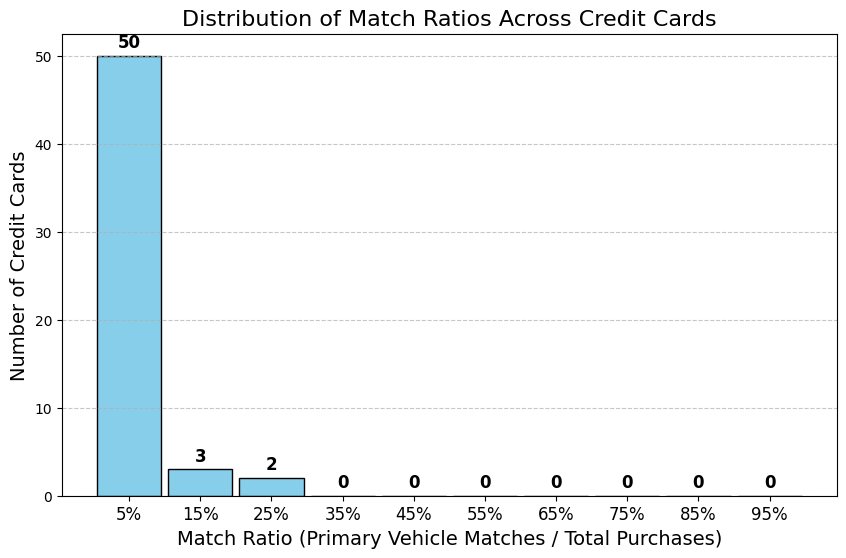

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# --- Plot Corrected Histogram ---

# 1. Setup the figure
plt.figure(figsize=(10,6))

# 2. Define bins cleanly (0–0.1, 0.1–0.2, ..., 0.9–1.0)
bins = np.linspace(0, 1, 11)  # 10 bins exactly between 0 and 1

# 3. Create the histogram
counts, bin_edges, patches = plt.hist(
    primary_vehicle_summary_df['match_ratio_to_primary'],
    bins=bins,
    edgecolor='black',
    color='skyblue',
    rwidth=0.9
)

# 4. Title and Labels
plt.title('Distribution of Match Ratios Across Credit Cards', fontsize=16)
plt.xlabel('Match Ratio (Primary Vehicle Matches / Total Purchases)', fontsize=14)
plt.ylabel('Number of Credit Cards', fontsize=14)

# 5. Set exact ticks at bin centers
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
plt.xticks(bin_centers, [f'{int(b*100)}%' for b in bin_centers], fontsize=12)

# 6. Annotate each bar with its count
for count, x in zip(counts, bin_centers):
    plt.text(x, count + 0.5, int(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

# 7. Grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 8. Show
plt.show()


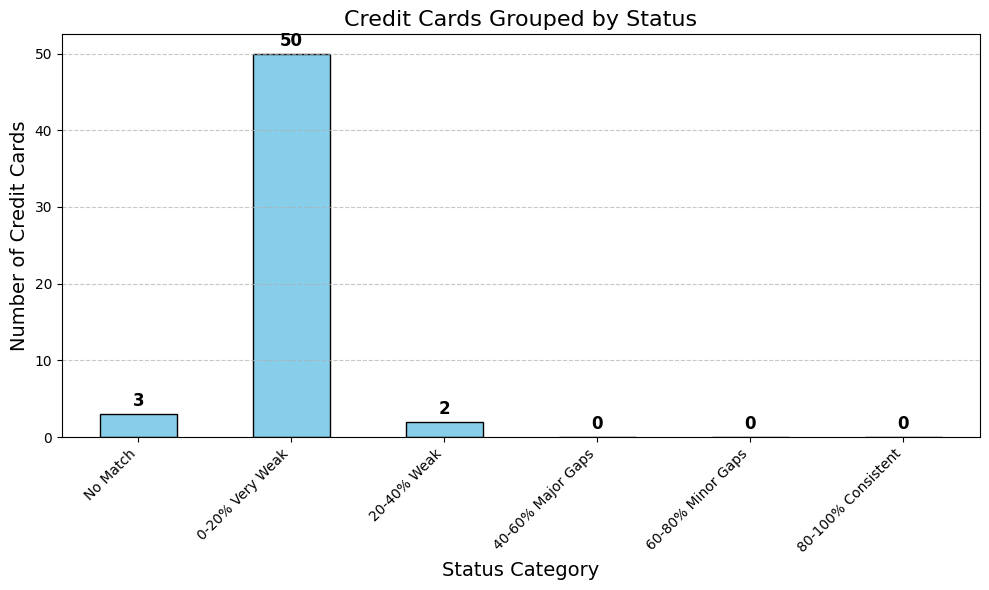

In [13]:
import matplotlib.pyplot as plt

# --- 1. Define all possible status categories manually
status_order = [
    'No Match', '0-20% Very Weak', '20-40% Weak', '40-60% Major Gaps', '60-80% Minor Gaps', '80-100% Consistent']

# --- 2. Group and count

# Ensure the status column is categorical with all statuses
primary_vehicle_summary_df['status'] = pd.Categorical(primary_vehicle_summary_df['status'], categories=status_order, ordered=True)

# Now count
category_counts = primary_vehicle_summary_df['status'].value_counts().sort_index()

# --- 3. Plot ---

plt.figure(figsize=(10,6))

# Bar plot
ax = category_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Title and labels
plt.title('Credit Cards Grouped by Status', fontsize=16)
plt.xlabel('Status Category', fontsize=14)
plt.ylabel('Number of Credit Cards', fontsize=14)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# Annotate counts above bars
for i, count in enumerate(category_counts):
    plt.text(i, count + 0.5, str(int(count)), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Layout
plt.tight_layout()

# Show plot
plt.show()


In [25]:
import pandas as pd

# Load GPS data
gps_df = pd.read_csv("../cleaned_data/gps_data_cleaned.csv", parse_dates=["timestamp"])

# Sort by car and time
gps_df = gps_df.sort_values(by=["id", "timestamp"])

# Compute time difference in seconds between points per car
gps_df["time_diff"] = gps_df.groupby("id")["timestamp"].diff().dt.total_seconds()

# Mark idle as True if gap > 15 minutes
gps_df["is_idle"] = gps_df["time_diff"] > 900

# Add date and hour fields
gps_df["date"] = gps_df["timestamp"].dt.date
gps_df["hour"] = gps_df["timestamp"].dt.hour

# Aggregate to (car, date, hour) level
agg = gps_df.groupby(["id", "date", "hour"]).agg(
    has_idle=("is_idle", "any")  # True if any idle period in this hour
).reset_index()

# Create all combinations of car/date/hour to detect missing
all_ids = gps_df["id"].unique()
all_dates = gps_df["timestamp"].dt.date.unique()
all_hours = range(24)
full_index = pd.MultiIndex.from_product([all_ids, all_dates, all_hours], names=["id", "date", "hour"])
full_df = pd.DataFrame(index=full_index).reset_index()

# Merge in aggregated results
merged = full_df.merge(agg, on=["id", "date", "hour"], how="left")

# Assign status:
# 1 = idle, 0 = active, -1 = no data
merged["status"] = merged["has_idle"].map({True: 1, False: 0})
merged["status"] = merged["status"].fillna(-1).astype(int)

# Final output
idle_matrix = merged[["id", "date", "hour", "status"]]
valid_ids = idle_matrix["id"].unique()
idle_matrix = idle_matrix[idle_matrix["id"].isin(valid_ids)]
idle_matrix.to_csv("plots/cleaned_idle_matrix.csv", index=False)

In [15]:
print(gps_df["id"].dtype)
print(gps_df["id"].unique())
print(idle_matrix["id"].unique())
print("Unexpected IDs:", set(idle_matrix["id"].unique()) - set(gps_df["id"].unique()))


int64
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35 101
 104 105 106 107]
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35 101
 104 105 106 107]
Unexpected IDs: set()


In [16]:
display(idle_matrix)

,id,date,hour,status
0,1,2014-01-06,0,-1
1,1,2014-01-06,1,-1
2,1,2014-01-06,2,-1
3,1,2014-01-06,3,-1
4,1,2014-01-06,4,-1
...,...,...,...,...
13435,107,2014-01-19,19,-1
13436,107,2014-01-19,20,-1
13437,107,2014-01-19,21,-1
13438,107,2014-01-19,22,-1


In [17]:
display(valid_ids)

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35, 101, 104, 105, 106,
       107])

In [18]:
import plotly.graph_objects as go
import pandas as pd
from ipywidgets import interact, Dropdown
import pandas as pd


def plot_idle_heatmap(data, selected_date):
    # Filter for selected date
    day_df = data[data["date"] == pd.to_datetime(selected_date).date()]
    
    # Pivot for heatmap
    heatmap_data = day_df.pivot(index="id", columns="hour", values="status").fillna(-1).sort_index()

    # New smooth colorscale: red (-1) → blue (0) → white (1)
    colorscale = [
        [0.0, "blue"],        # -1
        [0.5, "orange"],       # 0
        [1.0, "red"]       # 1
    ]
    
    fig = go.Figure(data=go.Heatmap(
        z=heatmap_data.values,
        x=heatmap_data.columns,
        y=heatmap_data.index.astype(str),  # treat IDs as categories, not numbers
        colorscale=colorscale,
        colorbar=dict(
            title="Status",
            tickvals=[-1, 0, 1],
            ticktext=["No Data", "Active", "Idle"]
        ),
        zmin=-1,
        zmax=1
    ))

    # Inside your function, just before the title:
    date_obj = pd.to_datetime(selected_date)
    day_name = date_obj.strftime("%A")
    
    fig.update_layout(
        title=f"Idle Status Heatmap for {selected_date} ({day_name})",
        xaxis_title="Hour of Day",
        yaxis_title="Car ID",
        height=600
    )

    fig.show()

import plotly.express as px
import pandas as pd

def plot_status_bars(data, selected_date):
    df = data[data["date"] == pd.to_datetime(selected_date).date()]
    
    # Count hours by status for each car
    summary = df.groupby("id")["status"].value_counts().unstack(fill_value=0)
    summary = summary.rename(columns={-1: "no_data_hours", 0: "active_hours", 1: "idle_hours"})

    for col in ["no_data_hours", "active_hours", "idle_hours"]:
        if col not in summary:
            summary[col] = 0

    # Helper to create and show bar charts
    def plot_bar(metric_name, title_prefix, color):
        top_5 = summary.sort_values(metric_name, ascending=False).head(5).reset_index()
        bottom_5 = summary.sort_values(metric_name, ascending=True).head(5).reset_index()

        # Convert 'id' to string so x-axis is categorical
        top_5["id"] = top_5["id"].astype(str)
        bottom_5["id"] = bottom_5["id"].astype(str)

        fig_top = px.bar(
            top_5, x="id", y=metric_name, 
            title=f"Top 5 Cars with Most {title_prefix}",
            color_discrete_sequence=[color]
        )
        fig_bottom = px.bar(
            bottom_5, x="id", y=metric_name, 
            title=f"Bottom 5 Cars with Least {title_prefix}",
            color_discrete_sequence=[color]
        )

        fig_top.update_layout(xaxis_title="Car ID", yaxis_title="Hours", xaxis_type="category")
        fig_bottom.update_layout(xaxis_title="Car ID", yaxis_title="Hours", xaxis_type="category")

        fig_top.show()
        fig_bottom.show()

    print(f"📊 Bar Chart Summary for {selected_date} ({pd.to_datetime(selected_date).strftime('%A')}):")

    plot_bar("no_data_hours", "No Data Hours", "red")
    plot_bar("active_hours", "Active Hours", "blue")
    plot_bar("idle_hours", "Idle Hours", "green")


In [19]:
# Get unique, sorted dates
available_dates = sorted(idle_matrix["date"].unique())

# Define interactive plot
@interact(selected_date=Dropdown(options=available_dates, description="Select Date"))
def update_heatmap(selected_date):
    plot_idle_heatmap(idle_matrix, selected_date)
    plot_status_bars(idle_matrix, selected_date)

interactive(children=(Dropdown(description='Select Date', options=(datetime.date(2014, 1, 6), datetime.date(20…

## Linking People to Cars (map)

**1. Load Data**

In [23]:
import pandas as pd
import plotly.express as px

# Load GPS tracking data
gps_df = pd.read_csv('../cleaned_data/gps_data_cleaned.csv')

# Load Car Assignments
car_assignments = pd.read_csv('../cleaned_data/car_assignments_cleaned.csv')

**2. Prepare Data**

In [24]:
# Convert GPS timestamps to datetime
gps_df['timestamp'] = pd.to_datetime(gps_df['timestamp'])

# Create a "Person Name" field: Firstname + Lastname initial
car_assignments['person_name'] = car_assignments['firstname'] + ' ' + car_assignments['lastname'].str[0] + '.'

# Merge GPS with car assignment (vehicle id -> person)
merged_gps = gps_df.merge(car_assignments, left_on='id', right_on='carid', how='left')

merged_gps_filtered['timestamp_1min'] = merged_gps_filtered['timestamp'].dt.round('5min')

# Preview to make sure it looks correct
print(merged_gps[['timestamp', 'id', 'lat', 'long', 'person_name']].head())

NameError: name 'merged_gps_filtered' is not defined

**3. Create Animated Map**

In [ ]:
fig = px.scatter_mapbox(
    merged_gps,
    lat='lat',
    lon='long',
    color='person_name',                              # Color dots by person
    animation_frame=merged_gps['timestamp'].dt.strftime('%Y-%m-%d %H:%M:%S'),  # Animate by second
    hover_name='person_name',                         # Show person name when hovering
    zoom=13,                                          # Zoom level for Abila
    height=800
)

# Update map layout
fig.update_layout(
    mapbox_style="open-street-map",                   # Use OpenStreetMap
    title="Employee Movements Over Time",
    title_x=0.5,
    margin={"r":0,"t":50,"l":0,"b":0}
)

# Display the map
fig.show()

/var/folders/gz/b07vrg811_b1gw2cvpntg_kr0000gn/T/ipykernel_8777/3761089739.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(
